# ICS - Travaux Pratiques 12

21.05.25


<font color=grey>_Dans ce 12e TP, nous reviendrons sur les formules d'interpolations de polynômes en utilisant les polynomes de Lagrange. Nous étudierons également les premières méthodes d'intégration numérique vues en cours.._ 

_Note : ne vous sentez pas obligé.e.s de finir la série pendant la séance! Celle-ci est conçue de manière à ce que vous gardiez certains exercices pour vos révisions._ </font>

***

In [1]:
# importation des librairies numpy et matplotlib que nous allons utiliser dans ce notebook  
import numpy as np
import matplotlib.pyplot as plt

## Exercice 1 : interpolation de Lagrange
  

Dans cet exercice, on revient sur la **méthode d'interpolation de Lagrange** qui permet de construire le polynôme $p\in \mathbb{P}_n$ passant par $n+1$ points. On vous demande en particulier... 
1) ...de déterminer l'expression du **polynôme d'interpolation** $p(t)$ passant par :
* les deux points $P_0=(t_0,p_0)$ et $P_1=(t_1,p_1)$ ;
* les trois points $P_0=(t_0,p_0)$, $P_1=(t_1,p_1)$ et $P_2=(t_2,p_2)$.

2) ...de représenter ces deux polynômes en posant $P_0=(1,4)$, $P_1=(4,7)$ et $P_2=(7,-3)$.

Plus précisément, on vous demande 
   * de représenter, dans deux graphiques placés côte à côte dans la même figure de 12 pouces sur 6 pouces, les deux polynômes $p(t)$ obtenus,  ainsi que les points $P_0$, $P_1$ et $P_2$.
   * de représenter également, dans ces mêmes graphiques, en pointillés, les polynômes correspondant à chacun des termes $p_j\varphi_j(t)$, avec $j=0,1$ , respectivement $j=0,1,2$ , intervenant dans la combinaison linéaire définissant les deux polynômes d'interpolation $p$. Indiquez sur la représentation le (ou les) zéro(s) de ces polynômes.
   * d'afficher un titre et une légende de manière à rendre la figure la plus lisible possible.

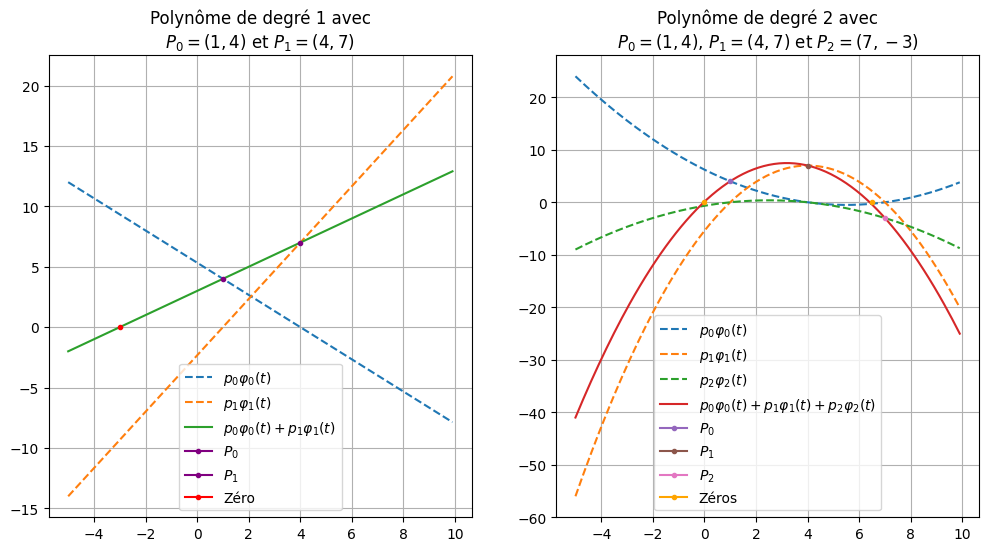

In [43]:
def phi(x, x_n, x_k):
    final_phi = 1
    
    for x_j in x_n:
        if x_j != x_k:
            final_phi *= (x-x_j)/(x_k-x_j)
    
    return final_phi    
    

def polynome(x, P):
    p_j = [] # Chaque polynome
    p_x = 0 # Polynome formmé de l'addition des p_j
    x_n = [P_i[0] for P_i in P]
    
    for P_i, x_i in enumerate(x_n):
        x_copy = x.copy()
        p_j.append(P[P_i][1]*phi(x_copy, x_n, x_i))
        
    for p_i in p_j:
        p_x += p_i
    
    return (p_j, p_x)
    
    

a = -5
b = 10
    
x = np.arange(a, b, .1)

polynomes_1_j, polynome_1 = polynome(x, [(1,4), (4,7)])
polynomes_2_j, polynome_2 = polynome(x, [(1,4), (4,7), (7,-3)])



fig, ax = plt.subplots(1, 2)


ax[0].grid()
ax[0].set_title("Polynôme de degré 1 avec\n" + r"$P_0=(1,4)$ et $P_1=(4,7)$")

for j, polynome in enumerate(polynomes_1_j):
    ax[0].plot(x, polynome, linestyle="--", label=(rf"$p_{j}\varphi_{j}(t)$"))
        
ax[0].plot(x, polynome_1, label=r"$p_0\varphi_0(t) + p_1\varphi_1(t)$")

ax[0].plot(1, 4, marker=".", color="purple", label=r"$P_0$")
ax[0].plot(4, 7, marker=".", color="purple", label=r"$P_1$")

ax[0].plot(-3, 0, marker=".", color="red", label="Zéro")


ax[1].grid()
ax[1].set_title("Polynôme de degré 2 avec\n" + r"$P_0=(1,4)$, $P_1=(4,7)$ et $P_2=(7,-3)$")

for j, polynome in enumerate(polynomes_2_j):
    ax[1].plot(x, polynome, linestyle="--", label=rf"$p_{j}\varphi_{j}(t)$")
    
ax[1].plot(x, polynome_2, label=r"$p_0\varphi_0(t) + p_1\varphi_1(t) + p_2\varphi_2(t)$")
        
ax[1].plot(1, 4, marker=".", label=r"$P_0$")
ax[1].plot(4, 7, marker=".", label=r"$P_1$")
ax[1].plot(7, -3, marker=".", label=r"$P_2$")

ax[1].plot(0, 0, marker=".", color="orange", label="Zéros")
ax[1].plot(6.5, 0, marker=".", color="orange")


fig.set_figwidth(12)
fig.set_figheight(6)

ax[0].legend()
ax[1].legend()
plt.show()

***

## Exercice 2 : Méthodes de quadrature non composites

<font color=grey>**Rappel**

Le principe général des **méthodes non composites** est de remplacer le calcul de l'intégrale définie d'une fonction $f(x)$ entre $a$ et $b$, 
$$
I = \int_{a}^{b}{f(x)dx}\,,
$$
(c'est-à-dire le calcul de l'aire sous la courbe, avec signe) par l'évaluation de la superficie qui se trouve sous la courbe correspondant à un polynôme d'interpolation $p\in \mathbb{P}_n$ passant par $n+1$ points $(x,f(x))$ :
$$
I_n = \int_{a}^{b}{p(x)dx}\,.
$$

Selon la valeur de $n$ (c'est-à-dire selon le nombre de points d'interpolation considérés), on peut donc distinguer :
* les **méthodes du "point de gauche"**, **du "point de droite"**, **du "point milieu"** ou **de Riemann** qui correspondent au cas $n=0$. 
On fait alors passer une **fonction constante** par l'**unique point** choisi : 
    * $(a,f(a))$ (*point de gauche*) , 
    * $(b,f(b))$ (*point de droite*) ,
    * $(\frac{a+b}{2},f(\frac{a+b}{2}))$ (*point milieu*) ,
    * $(\xi,f(\xi))$ (*point choisi au hasard*) ;
* la **méthode du trapèze** qui correspond au cas $n=1$. 
On fait alors passer une **fonction affine** (droite) par les **deux points** choisis :
    * en général, $(a,f(a))$ et $(b,f(b))$ ;
* d'**autres méthodes** (**Simpson**, etc.) que nous aurons l'occasion d'étudier plus tard.</font>


Dans cet exercice, nous allons considérer la fonction réelle d'une variable réelle $f: \mathbb{R}\rightarrow \mathbb{R}$ définie par :

$$
f(x) = (x^2-2x)\exp{(-x)}\,.
$$
Plus précisément, on vous demande de :
* représenter la fonction $f(x)$ sur l'intervalle $[0,6.5]$ ;
* calculer numériquement la valeur approchée des intégrales $I_1 = \int_{0.5}^{4}{f(x)dx}$ et 
$I_2 = \int_{4}^{6}{f(x)dx}$ en utilisant les **méthodes de quadrature non composites** énumérées plus haut (méthodes du *point de gauche*, du *point de droite*, du *point milieu*, de *Riemann* (*point choisi au hasard*) et du *trapèze*). <br>
Pour ce faire, on vous propose de définir une fonction `integration_noncomposite` admettant comme arguments : la fonction `f` à intégrer, les bornes `a` et `b` de l'intervalle d'intégration considéré, ainsi que la `methode` choisie (`gauche`, `droite`, `milieu`, `riemann` ou `trapeze`). <br>
Cette fonction devra afficher un message d'erreur 
    - si $a\ge b$ ;  
    - si la méthode précisée en argument ne fait pas partie des méthodes prises en charge par la fonction. 

  L'implémentation de la méthode de Riemann, doit se faire grâce à la fonction `random.uniform()` du module `random` de Python pour déterminer un point au hasard dans l'intervalle $[a,b]$ (`random.uniform(a,b)`).<br>
Vos résultats devront être affichés clairement à l'aide de quelques instructions `print()`. <br>
Dans le cas de la *méthode du trapèze*, on vous demande de plus de représenter la fonction $f(x)$ en mettant en évidence l'aire calculée à l'aide de la méthode `plt.fill()` qui permet de colorier l'intérieur d'un polygone.
* discuter vos résultats en les comparant entre eux et avec les valeurs exactes obtenues en cherchant la primitive de $f$ :

$$
I_1 \cong -0.1414175573 ~~~~\text{et}~~~~I_2 \cong 0.2038151439\,.
$$

In [ ]:
a = 0
b = 6.5

***

## Exercice 3 :  Méthodes de quadrature composites


<font color=grey>**Rappel** 

Sur un intervalle $[a,b]$ grand, il est possible d'appliquer une méthode de quadrature non composite telle que décrite ci-dessus en prenant soin de considérer un polynôme $p\in \mathbb{P}_n$ avec $n$ grand (de manière à interpoler le mieux possible la fonction $f(x)$ sur l'intervalle). Toutefois, il est souvent préférable d'appliquer une **méthode de quadrature composite** : on divise l'intervalle $[a,b]$ en un certain nombre de sous-intervalles (autrement dit, on crée une partition de $[a,b]$) dans lesquels on interpole grâce à des polynômes $p\in \mathbb{P}_n$ avec $n$ petit. </font>

Dans cet exercice, on vous propose d'affiner le calcul des intégrales définies $I_1$ et $I_2$ déjà abordé à l'exercice 2. Plus précisément, on vous demande de :
* définir une fonction `integration_composite` admettant comme arguments : la fonction `f` à intégrer, les bornes `a` et `b` de l'intervalle d'intégration, le nombre `n` de sous-intervalles de la partition (que l'on supposera régulière) considérée, ainsi que la méthode (unique) choisie (`gauche`, `droite`, `milieu`, `riemann` ou `trapeze`) pour intégrer chacun des sous-intervalles. Cette fonction devra utiliser la fonction `integration_noncomposite` de l'exercice 2 ;
* calculer les intégrales définies $I_1$ et $I_2$ à l'aide des différentes méthodes ;
* faire varier le nombre de sous-intervalles (c'est-à-dire de modifier la **finesse de la partition**) et d'observer l'incidence sur les valeurs obtenues ;
* deviner une manière d'estimer l'erreur commise dans le calcul.